# Credit Approval Compliance & Fair Lending Risk Analysis

## 1. Business & Regulatory Context

- Banks must comply with credit regulations to ensure fair lending and prevent discrimination.
- Regulatory rules require:
  - No systematic bias in loan approvals (gender, education, home status, etc.)
  - Risk awareness in lending decisions (high-risk applicants)
- Project goal: Analyze loan approval fairness and risk profiling using historical loan data.

## 2. Analytical Questions

- Are approvals biased by gender, education, or home ownership?
- How do income, credit history, previous defaults, and credit score affect approval rates?
- Which applicant segments are higher risk?
- How can banks improve fairness and compliance based on the data?

## 3. Dataset Loading & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Path to dataset files:", path)

/Users/apple/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Path to dataset files: /Users/apple/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1


In [2]:
import os

files = os.listdir(path)
print(files)

['loan_data.csv']


In [3]:
file_path = os.path.join(path, "loan_data.csv")
df = pd.read_csv(file_path)

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


> Dataset contains 45,000 records with 14 columns, including both categorical and numerical features

> Target variable: loan_status (1 = approved, 0 = rejected)

## 4. Data Cleaning & Preprocessing

In [6]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
df['person_age'] = df['person_age'].clip(18, 100)

In [8]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   person_age                      45000 non-null  float64 
 1   person_gender                   45000 non-null  category
 2   person_education                45000 non-null  category
 3   person_income                   45000 non-null  float64 
 4   person_emp_exp                  45000 non-null  int64   
 5   person_home_ownership           45000 non-null  category
 6   loan_amnt                       45000 non-null  float64 
 7   loan_intent                     45000 non-null  category
 8   loan_int_rate                   45000 non-null  float64 
 9   loan_percent_income             45000 non-null  float64 
 10  cb_person_cred_hist_length      45000 non-null  float64 
 11  credit_score                    45000 non-null  int64   
 12  previous_loan_defa

> Some ages were unrealistic, capped between 18-100

> Categorical variables converted to category type for analysis

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

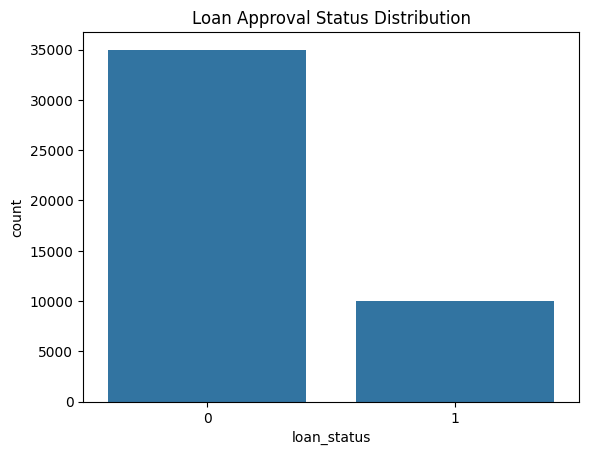

In [9]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Status Distribution")
plt.show()

> The bar chart displays the distribution of loan approvals, where 0 represents rejected and 1 represents approved applications. It is evident that the number of rejections (~ 35,000) significantly exceeds the number of approvals (~ 10,000), indicating a substantial imbalance in approval outcomes.

> This disparity highlights potential constraints or selectivity in the current credit approval process. Such imbalance warrants further analysis to investigate whether specific applicant characteristics (e.g., income, credit history, gender, or home ownership) systematically influence approval decisions, which is critical for ensuring fair lending compliance and identifying potential areas of regulatory risk.

### 5.2 Gender vs Approvals

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/1121013809.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_approval = df.groupby('person_gender')['loan_status'].mean().reset_index()


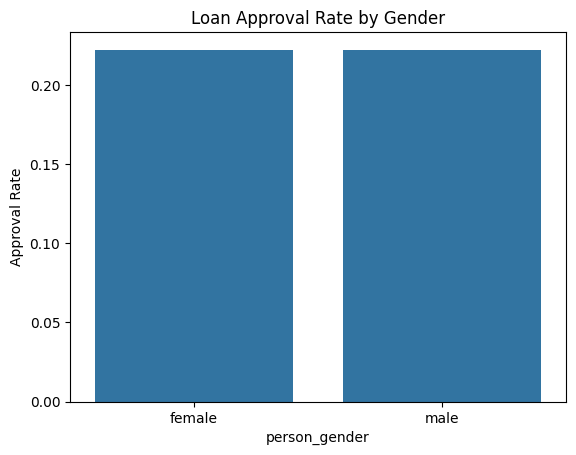

In [10]:
gender_approval = df.groupby('person_gender')['loan_status'].mean().reset_index()
sns.barplot(x='person_gender', y='loan_status', data=gender_approval)
plt.ylabel("Approval Rate")
plt.title("Loan Approval Rate by Gender")
plt.show()

> The bar chart illustrates the loan approval rate by gender. Both Female and Male applicants exhibit relatively similar approval rates, each around 20%, indicating no immediate evidence of gender-based bias in the credit approval process within the dataset. Such parity aligns with the principles of fair lending compliance.

> Despite the comparable overall approval rates, further analysis is warranted to examine whether other applicant characteristics (e.g., education and home ownership) might influence approval outcomes. This deeper investigation is essential to uncover subtle patterns of systematic bias that could pose regulatory risk.

### 5.3 Education vs Approval

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/1228707518.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edu_approval = df.groupby('person_education')['loan_status'].mean().reset_index()


Text(0.5, 1.0, 'Loan Approval Rate by Education')

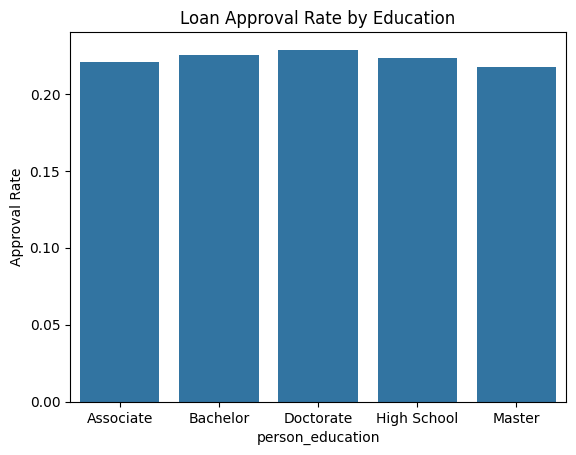

In [11]:
edu_approval = df.groupby('person_education')['loan_status'].mean().reset_index()
sns.barplot(x='person_education', y='loan_status', data=edu_approval)
plt.ylabel("Approval Rate")
plt.title("Loan Approval Rate by Education")

> The bar chart presents the loan approval rate across different education levels, including Associate, Bachelor, Doctorate, High School, and Master. The approval rates appear relatively uniform across all education categories, with each level around 20% and no education group exhibiting a markedly higher or lower approval rate compared to others.

> This consistency suggests that education level, in isolation, is not a primary driver of loan approval decisions within the dataset. From a compliance perspective, this pattern aligns with fair lending principles, as it indicates no evident educational bias in the approval process.

### 5.4 Home Ownership vs Approval

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/2369839534.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  home_approval = df.groupby('person_home_ownership')['loan_status'].mean().reset_index()


Text(0.5, 1.0, 'Loan Approval Rate by Home Ownership')

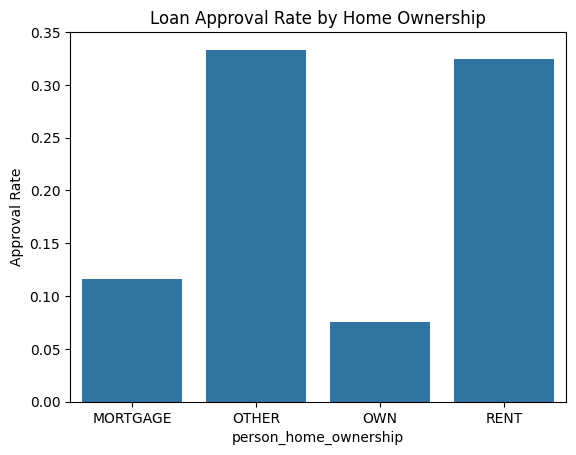

In [12]:
home_approval = df.groupby('person_home_ownership')['loan_status'].mean().reset_index()
sns.barplot(x='person_home_ownership', y='loan_status', data=home_approval)
plt.ylabel("Approval Rate")
plt.title("Loan Approval Rate by Home Ownership")

> The bar chart illustrates the loan approval rate by home ownership status, revealing notable variation across categories. Applicants classified as Other and Rent exhibit the highest approval rates, reaching approximately 30-35%, while Mortgage applicants show a substantially lower approval rate, around 10%. In contrast, applicants who own their homes record the lowest approval rate, ranging between 5-10%.

> This disparity suggests that home ownership status may play a meaningful role in credit approval decisions within the dataset. From a risk and compliance perspective, such differences warrant further investigation to determine whether home ownership status serves as a proxy for other financial risk factors (e.g., income stability, debt burden, or loan-to-value exposure) or whether it introduces unintended bias in the approval process.



### 5.5 Income Level vs Approval

In [13]:
income_bins = [0, 30000, 60000, 100000, 200000, df['person_income'].max()]
income_labels = ['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']

df['income_band'] = pd.cut(
    df['person_income'],
    bins=income_bins,
    labels=income_labels
)

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/2424776464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_approval = df.groupby('income_band')['loan_status'].mean().reset_index()


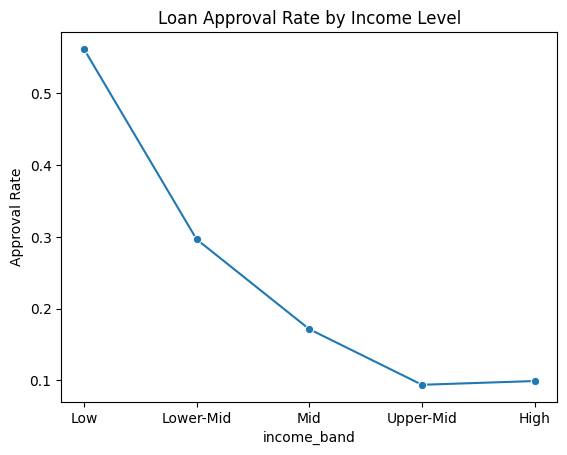

In [14]:
income_approval = df.groupby('income_band')['loan_status'].mean().reset_index()
sns.lineplot(
    x='income_band',
    y='loan_status',
    data=income_approval,
    marker='o'
)
plt.ylabel("Approval Rate")
plt.title("Loan Approval Rate by Income Level")
plt.show()

> The line chart illustrates a clear downward trend in loan approval rates as income levels increase. Applicants in the Low income segment exhibit the highest approval rate, exceeding 50%, followed by the Lower-Middle income group at approximately 30%. Approval rates decline further for the Middle income segment (around 20%) and drop to roughly 10% for both Upper-Middle and High income groups.

> This inverse relationship between income level and approval likelihood is counterintuitive from a traditional credit risk perspective, where higher income is generally associated with lower default risk. From a compliance and risk governance standpoint, this pattern warrants deeper investigation to assess whether income is interacting with other factors, such as loan amount, loan-to-income ratio, or credit history or whether structural decision rules are disproportionately constraining higher-income applicants. Such behavior may indicate hidden policy thresholds or unintended bias that could introduce regulatory and fair-lending risk.

## 6. Applicant Financial Profile Analysis

### 6.1 Loan Amount

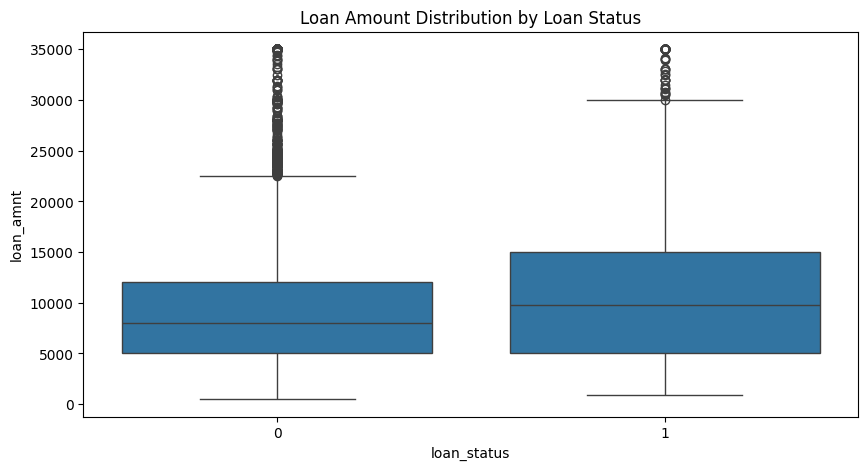

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title("Loan Amount Distribution by Loan Status")
plt.show()

> The boxplot shows that loan amount strongly influences approval decisions. Most rejected applications involve relatively smaller loan amounts, but many higher loan requests fall outside the normal range and are rejected early. In contrast, approved loans generally have higher loan amounts and a wider spread, indicating that the bank is willing to approve larger loans once applicants meet the required criteria. Extremely large loan amounts remain uncommon, suggesting they are treated as exceptional cases.

### 6.2 Credit Score & History

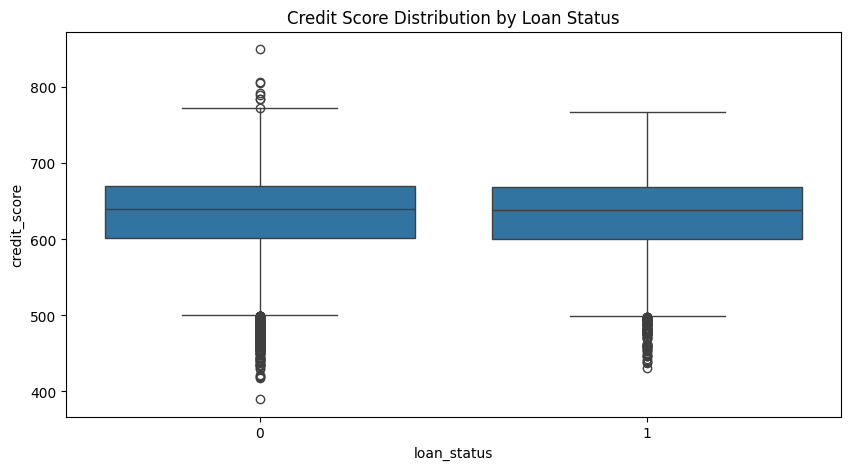

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title("Credit Score Distribution by Loan Status")
plt.show()

> The boxplot indicates that credit score alone does not clearly differentiate approved and rejected loans, as the main distribution (median and middle range) is very similar for both outcomes. The key difference lies in the outliers: rejected loans show more extreme values on both the lower and upper ends, while approved loans mainly exhibit low-end outliers and almost no unusually high credit scores. This suggests that although credit score is an important eligibility factor, it is likely used together with other variables (such as income, loan amount, or employment stability) rather than acting as a standalone decision driver.

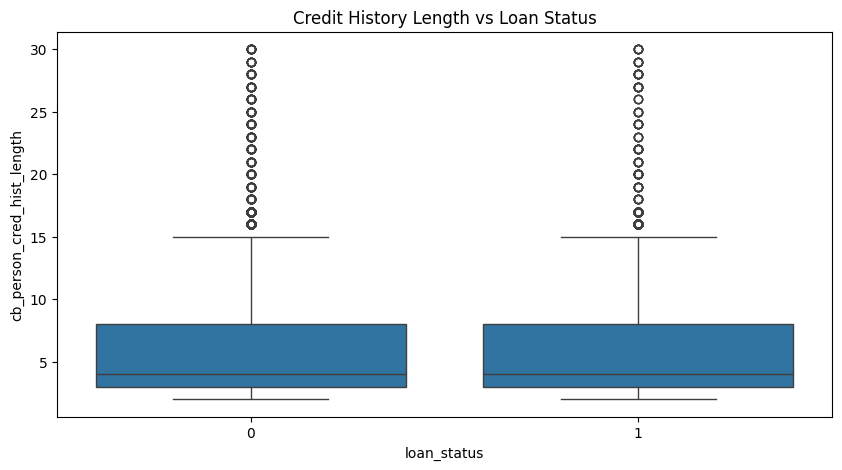

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df)
plt.title("Credit History Length vs Loan Status")
plt.show()

> In simple terms, the length of credit history is quite similar for both approved and rejected applicants. This means that having a longer credit history does not automatically guarantee loan approval. Instead, credit history length appears to act as a supporting factor rather than a primary determinant in credit decision-making.

## 7. Previous Loan Defaults

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/1708264438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_def = df.groupby('previous_loan_defaults_on_file')['loan_status'].mean().reset_index()


Text(0, 0.5, 'Loan Approval Rate by Previous Loan Defaults')

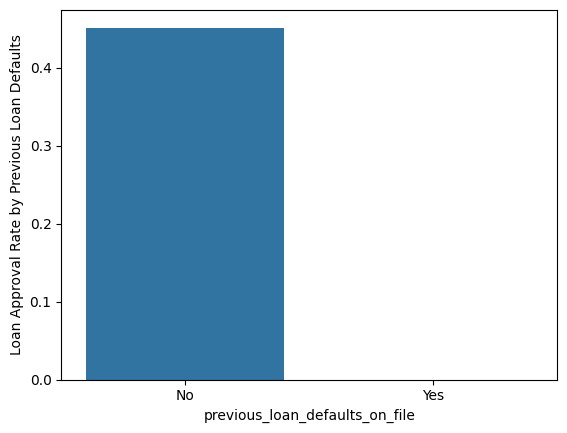

In [18]:
prev_def = df.groupby('previous_loan_defaults_on_file')['loan_status'].mean().reset_index()
sns.barplot(x='previous_loan_defaults_on_file', y='loan_status', data=prev_def)
plt.ylabel("Loan Approval Rate by Previous Loan Defaults")

> Previous default history is the most decisive factor in credit approval decisions. Within this dataset, none of the applicants with a prior loan default received approval, indicating that the bank treats default history as a strict “red flag.” As a result, other factors such as income or credit score appear to have limited influence once a prior default is identified.

## 8. Correlation & Feature Importance

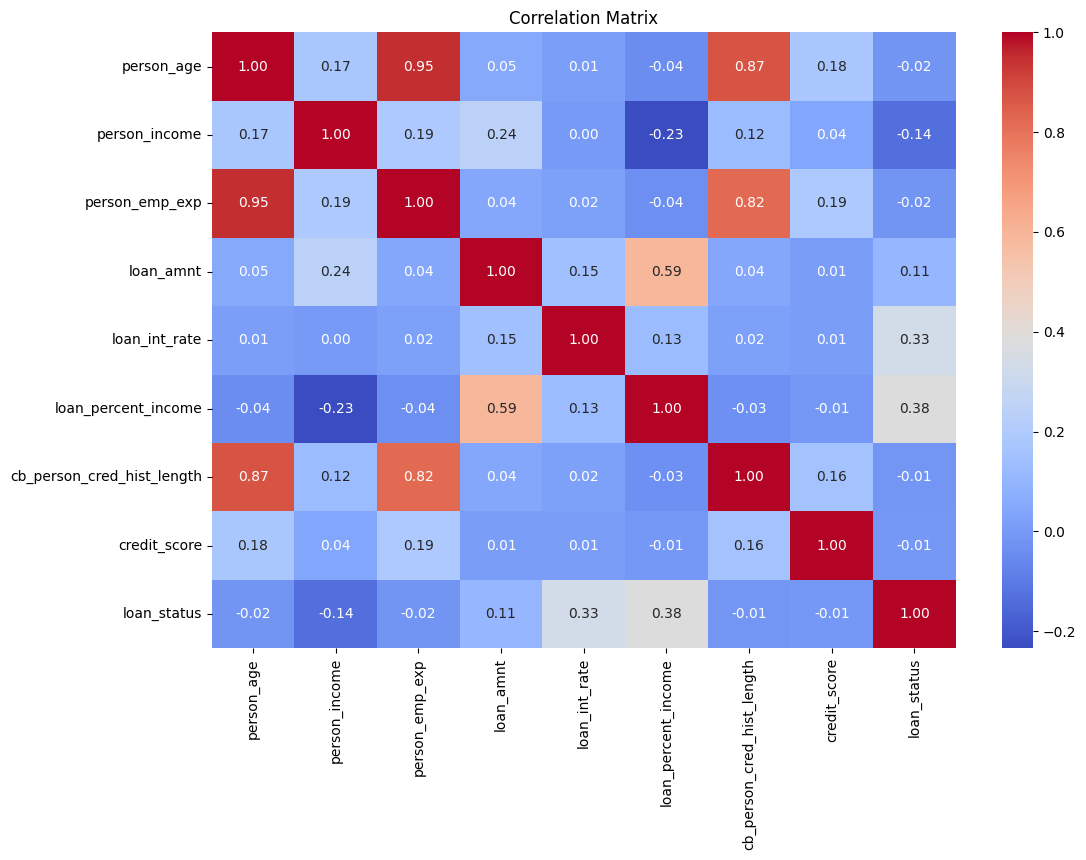

In [19]:
num_cols = ['person_age','person_income','person_emp_exp','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length','credit_score']

corr = df[num_cols + ['loan_status']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

> The correlation results show that age, work experience, and credit history length are very closely related, which is natural because older applicants usually have longer work and credit histories. Loan amount is moderately linked to how heavy the repayment burden is compared to income, meaning bigger loans tend to be harder to afford. Most importantly, loan approval is most strongly related to loan burden relative to income, indicating that applicants are more likely to be approved when their loan size is reasonable compared to their income. Overall, this suggests that credit decisions are mainly based on a borrower's ability to repay, rather than on personal or demographic characteristics.

## 9. Risk Profiling (High-Risk Segments)

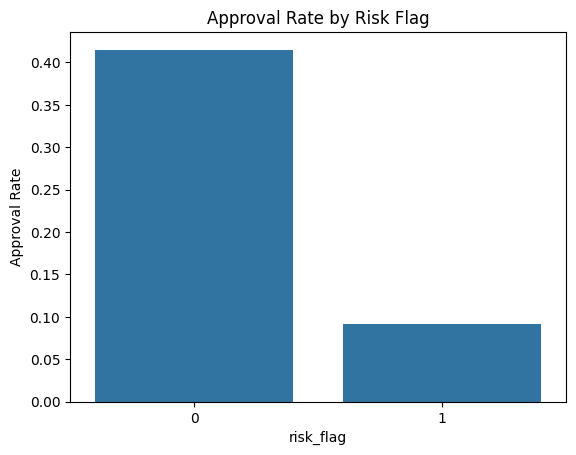

In [20]:
df['risk_flag'] = ((df['credit_score']<600) |
                   (df['loan_percent_income']>0.5) |
                   (df['previous_loan_defaults_on_file']=='Yes')).astype(int)

risk_summary = df.groupby('risk_flag')['loan_status'].mean().reset_index()
sns.barplot(x='risk_flag', y='loan_status', data=risk_summary)
plt.title("Approval Rate by Risk Flag")
plt.ylabel("Approval Rate")
plt.show()

> The chart shows a clear gap in approval rates between low-risk and high-risk applicants. Applicants classified as low risk (risk_flag = 0) have an approval rate exceeding 40%, while high-risk applicants (risk_flag = 1) have a much lower approval rate, around 10%.

> This pattern indicates that the credit approval process is strongly aligned with risk-based decision making. Applicants with poor credit indicators, such as low credit scores, high loan burden relative to income, or previous defaults, are significantly less likely to be approved. From a compliance perspective, this suggests that loan decisions are primarily driven by measurable financial risk factors rather than demographic characteristics, supporting prudent risk management and regulatory expectations.


## 10. Final Summary Table

In [21]:
summary = df.groupby(['person_gender','person_education','person_home_ownership']).agg(
    total_applicants=('loan_status','count'),
    approval_rate=('loan_status','mean'),
    avg_credit_score=('credit_score','mean'),
    avg_income=('person_income','mean')
).reset_index()

summary.sort_values('approval_rate', ascending=False)

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_5206/3120260835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['person_gender','person_education','person_home_ownership']).agg(


,person_gender,person_education,person_home_ownership,total_applicants,approval_rate,avg_credit_score,avg_income
1,female,Associate,OTHER,13,0.615385,633.000000,125373.692308
33,male,High School,OTHER,17,0.470588,621.647059,82281.176471
31,male,Doctorate,RENT,161,0.360248,658.173913,59269.198758
5,female,Bachelor,OTHER,20,0.350000,640.700000,82718.450000
7,female,Bachelor,RENT,3180,0.334277,638.625786,64289.065409
25,male,Bachelor,OTHER,21,0.333333,638.761905,96744.190476
27,male,Bachelor,RENT,3882,0.326893,637.856775,65987.169243
15,female,High School,RENT,2805,0.324421,619.064528,62921.971123
23,male,Associate,RENT,3469,0.323148,630.736235,64067.029403
3,female,Associate,RENT,2751,0.321338,628.313704,65560.381679


## 11. Actionable Recommendations

- Focus loan approvals on financial risk factors such as previous defaults, low credit scores, and high loan-to-income ratios.
- Check the impact of home ownership and high-income applicants to ensure no unintentional unfair treatment.
- Regularly monitor approvals by gender, education, and home ownership to detect any potential bias.
- Provide guidance or support for high-risk applicants to improve repayment chances while keeping lending safe for the bank.